# 05 Technical Agent

Generate a technical chart for a ticker and use a multimodal Azure OpenAI chat deployment to answer questions about the chart. The notebook stays thin: market-data loading, indicator calculation, charting, and multimodal message construction live in reusable project modules.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from IPython.display import Image, display

from market_analyst.config.settings import load_settings
from market_analyst.providers.market_data import fetch_price_history
from market_analyst.services.agents.technical import (
    DEFAULT_TECHNICAL_QUESTION,
    analyze_technical_chart,
    build_multimodal_chart_message,
)
from market_analyst.services.charting import (
    add_technical_indicators,
    generate_technical_chart,
    summarize_chart_artifact,
)
from market_analyst.telemetry import configure_notebook_logging
from market_analyst.types.technical import TechnicalAnalysisRequest

logger = configure_notebook_logging(run_name="05_technical_agent")
settings = load_settings()
settings.require_chat_model()

print("Project root:", PROJECT_ROOT)
print("Chat deployment:", settings.azure_openai_chat_deployment)

c:\Users\rushi\OneDrive - ImmersiLearn Education Services LLP\Projects\LLM Projects\market-analyst-feb26\.venv\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer
2026-05-10 12:21:05,430 INFO 05_technical_agent notebook_run_started


Project root: c:\Users\rushi\OneDrive - ImmersiLearn Education Services LLP\Projects\LLM Projects\market-analyst-feb26
Chat deployment: gpt-5.4-mini


## Run Configuration

Use a Yahoo Finance-compatible ticker. `QUESTION` is sent with the generated chart image to the multimodal model.

In [2]:
REQUEST = TechnicalAnalysisRequest(
    ticker="MSFT",
    period="6mo",
    interval="1d",
    question=DEFAULT_TECHNICAL_QUESTION,
)

OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "outputs" / "technical_charts"
print(REQUEST)

TechnicalAnalysisRequest(ticker='MSFT', question='Analyze the chart and explain the trend, momentum, support/resistance areas, breakout or breakdown risk, and a technical score from 0 to 100.', period='6mo', interval='1d')


## Fetch Prices And Generate Chart

Ticker: MSFT
Window: 2025-11-10 to 2026-05-08
Observations: 124
Latest close: 415.12
Latest RSI14: 53.89
Latest MACD: 5.88
Latest MACD signal: 6.96
Latest MACD histogram: -1.08


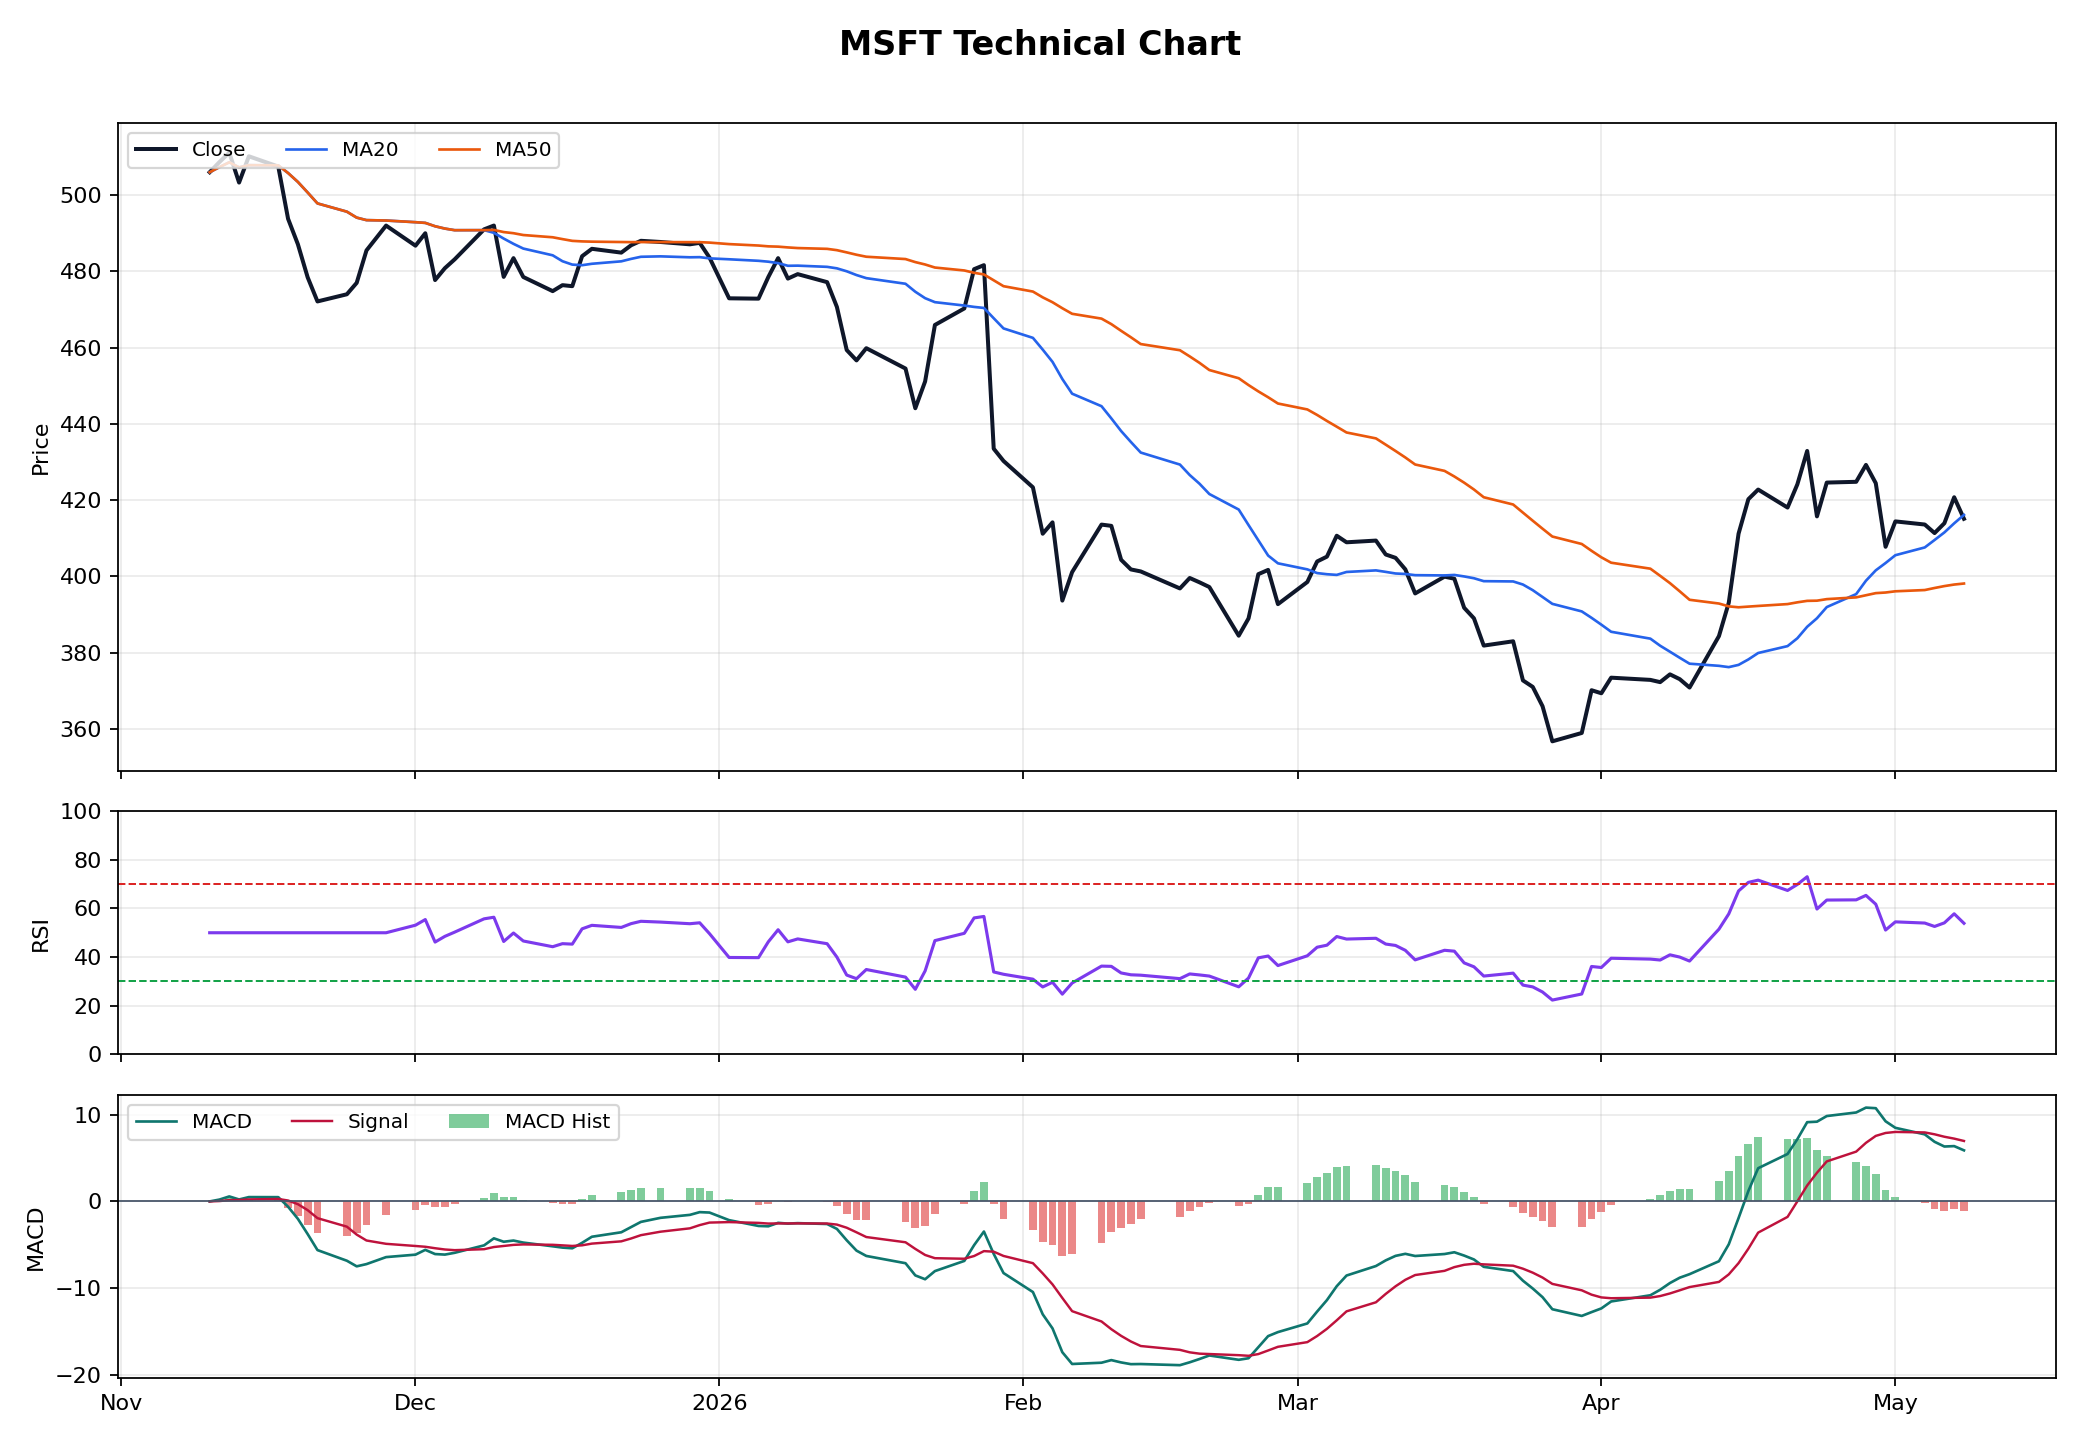

In [3]:
prices = fetch_price_history(REQUEST.ticker, period=REQUEST.period, interval=REQUEST.interval)
prices_with_indicators = add_technical_indicators(prices)
artifact = generate_technical_chart(REQUEST.ticker, prices_with_indicators, output_dir=OUTPUT_DIR)

print(summarize_chart_artifact(artifact))
display(Image(filename=str(artifact.chart_path)))

## Inspect Multimodal Payload

This confirms that the agent call will include one text part and one chart image part.

In [4]:
message = build_multimodal_chart_message(artifact=artifact, question=REQUEST.question)
print("Payload parts:", [part["type"] for part in message.content])
print(message.content[0]["text"][:900])

Payload parts: ['text', 'image_url']
You are the technical-analysis worker agent for a market intelligence system.

Use the attached chart image as the primary evidence. The chart includes close price,
20-day and 50-day moving averages, RSI14, and MACD. Answer the user's question with
specific observations from the chart. Return concise sections for trend, momentum,
support/resistance, risks, and technical score.

Chart metadata:
Ticker: MSFT
Window: 2025-11-10 to 2026-05-08
Observations: 124
Latest close: 415.12
Latest RSI14: 53.89
Latest MACD: 5.88
Latest MACD signal: 6.96
Latest MACD histogram: -1.08

Question:
Analyze the chart and explain the trend, momentum, support/resistance areas, breakout or breakdown risk, and a technical score from 0 to 100.



## Ask The Technical Agent

In [5]:
answer = analyze_technical_chart(settings, artifact=artifact, question=REQUEST.question)
print(answer)

2026-05-10 12:21:14,816 INFO httpx HTTP Request: POST https://ai-resources-e2e.cognitiveservices.azure.com/openai/deployments/gpt-5.4-mini/chat/completions?api-version=2025-04-01-preview "HTTP/1.1 200 OK"


## Trend
- **Primary trend is still recovering, but not fully bullish yet.** The chart shows a long decline from the 490–500 area into the mid-350s, followed by a rebound into the **415 area**.
- **Price is above the 20-day MA (~412) and above the 50-day MA (~398)**, which is constructive.
- However, the **50-day MA is still below the 20-day MA but both are flattening/upturning**, suggesting the downtrend has eased and a base/reversal is forming rather than a confirmed strong uptrend.

## Momentum
- **RSI14 = 53.89**: neutral-to-slightly bullish. It is above 50, but not strong enough to indicate overbought momentum.
- **MACD = 5.88 vs signal = 6.96, histogram = -1.08**: momentum has **softened recently**. MACD is still positive, but it is **below the signal line**, implying short-term upside momentum is fading.
- The recent rally from the April lows has lost some force, so momentum is **positive overall but weakening near current levels**.

## Support / Resistance
- **Support**
  - **~

## Validation

In [6]:
assert artifact.chart_path.exists(), "Technical chart image should exist."
assert artifact.observation_count > 20, "Technical analysis needs enough price observations."
assert str(answer).strip(), "Technical agent answer should not be empty."

print("Technical agent notebook validation passed.")

Technical agent notebook validation passed.
